In [1]:
# ================================
# 0. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# ================================
# 1. LOAD DATA
# ================================
# Replace with your file
df = pd.read_excel("/home/rajesh/work/ornella/proteomics/032526_Gabriela_HF1.xlsx")

# ================================
# 2. CLEAN DATA
# ================================

# Keep only high-confidence proteins
df = df[df['Protein FDR Confidence: Combined'] == 'High']

# Remove duplicates (keep highest abundance)
df = df.sort_values('Abundance: F2: Sample', ascending=False)
df = df.drop_duplicates(subset='Accession')

# Set protein identifier
df['Protein_ID'] = df['Accession']
df = df.set_index('Protein_ID')

# ================================
# 3. SELECT ABUNDANCE COLUMNS
# ================================
# Modify depending on your dataset
abundance_cols = [col for col in df.columns if 'Abundance' in col]

df_abundance = df[abundance_cols].copy()

# ================================
# 4. LOG TRANSFORMATION
# ================================
df_log = np.log2(df_abundance + 1)

# ================================
# 5. HANDLE MISSING VALUES
# ================================
imputer = KNNImputer(n_neighbors=3)
df_imputed = pd.DataFrame(imputer.fit_transform(df_log),
                         index=df_log.index,
                         columns=df_log.columns)

# ================================
# 6. NORMALIZATION (MEDIAN CENTERING)
# ================================
df_norm = df_imputed.subtract(df_imputed.median(axis=0), axis=1)

# ================================
# 7. PCA ANALYSIS
# ================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_norm.T)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, sample in enumerate(df_norm.columns):
    plt.text(X_pca[i,0], X_pca[i,1], sample)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA of Proteomics Data")
plt.grid()
plt.show()

# ================================
# 8. DIFFERENTIAL ANALYSIS
# ================================
# Define your groups (EDIT THIS)
groupA = ['Abundance: F1: Sample', 'Abundance: F2: Sample']
groupB = ['Abundance: F3: Sample', 'Abundance: F4: Sample']

results = []

for protein in df_norm.index:
    vals_A = df_norm.loc[protein, groupA].dropna()
    vals_B = df_norm.loc[protein, groupB].dropna()
    
    if len(vals_A) > 1 and len(vals_B) > 1:
        stat, pval = ttest_ind(vals_A, vals_B)
        log2fc = vals_B.mean() - vals_A.mean()
    else:
        pval = np.nan
        log2fc = np.nan
    
    results.append([protein, log2fc, pval])

res_df = pd.DataFrame(results, columns=['Protein', 'log2FC', 'pval'])

# Remove NA
res_df = res_df.dropna()

# Multiple testing correction
res_df['adj_pval'] = multipletests(res_df['pval'], method='fdr_bh')[1]

# ================================
# 9. FILTER SIGNIFICANT PROTEINS
# ================================
sig = res_df[(abs(res_df['log2FC']) > 1) & (res_df['adj_pval'] < 0.05)]

print(f"Significant proteins: {len(sig)}")

# ================================
# 10. VOLCANO PLOT
# ================================
plt.figure(figsize=(8,6))

sns.scatterplot(data=res_df,
                x='log2FC',
                y=-np.log10(res_df['adj_pval']),
                alpha=0.7)

# Highlight significant
sns.scatterplot(data=sig,
                x='log2FC',
                y=-np.log10(sig['adj_pval']),
                color='red')

plt.axhline(-np.log10(0.05), linestyle='--')
plt.axvline(1, linestyle='--')
plt.axvline(-1, linestyle='--')

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Volcano Plot")
plt.show()

# ================================
# 11. HEATMAP (SIGNIFICANT PROTEINS)
# ================================
if len(sig) > 1:
    heatmap_data = df_norm.loc[sig['Protein']]

    sns.clustermap(heatmap_data,
                   cmap='vlag',
                   standard_scale=0,
                   figsize=(10,10))

    plt.title("Heatmap of Differentially Abundant Proteins")
    plt.show()

# ================================
# 12. SAVE RESULTS
# ================================
res_df.to_csv("differential_proteins_full.csv", index=False)
sig.to_csv("significant_proteins.csv", index=False)

print("Analysis complete!")


ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'

In [27]:

# Replace with your file
df = pd.read_table("/home/rajesh/work/ornella/proteomics/new.csv")

# ================================
# 2. CLEAN DATA
# ================================

# Keep only high-confidence proteins

# Remove duplicates (keep highest abundance)
# df = df.sort_values('Abundance: F2: Sample', ascending=False)
# df = df.drop_duplicates(subset='Accession')

# # Set protein identifier
# df['Protein_ID'] = df['Accession']
# df = df.set_index('Protein_ID')

# # ================================
# # 3. SELECT ABUNDANCE COLUMNS
# # ================================
# # Modify depending on your dataset
# abundance_cols = [col for col in df.columns if 'Abundance' in col]

# df_abundance = df[abundance_cols].copy()

# # ================================
# # 4. LOG TRANSFORMATION
# # ================================
# df_log = np.log2(df_abundance + 1)


In [29]:
df.columns

Index(['Protein FDR Confidence: Combined', 'Accession', 'Description',
       'Coverage [%]', '# Peptides', '# PSMs', '# Unique Peptides', '# AAs',
       'MW [kDa]', 'Abundance: F2: Sample', 'Modifications'],
      dtype='object')

In [30]:
df[['Coverage [%]', '# Peptides', '# PSMs', 'Abundance: F2: Sample']].corr()


,Coverage [%],# Peptides,# PSMs,Abundance: F2: Sample
Coverage [%],1.000000,0.659255,0.533169,0.273095
# Peptides,0.659255,1.000000,0.514869,0.152231
# PSMs,0.533169,0.514869,1.000000,0.755998
Abundance: F2: Sample,0.273095,0.152231,0.755998,1.000000


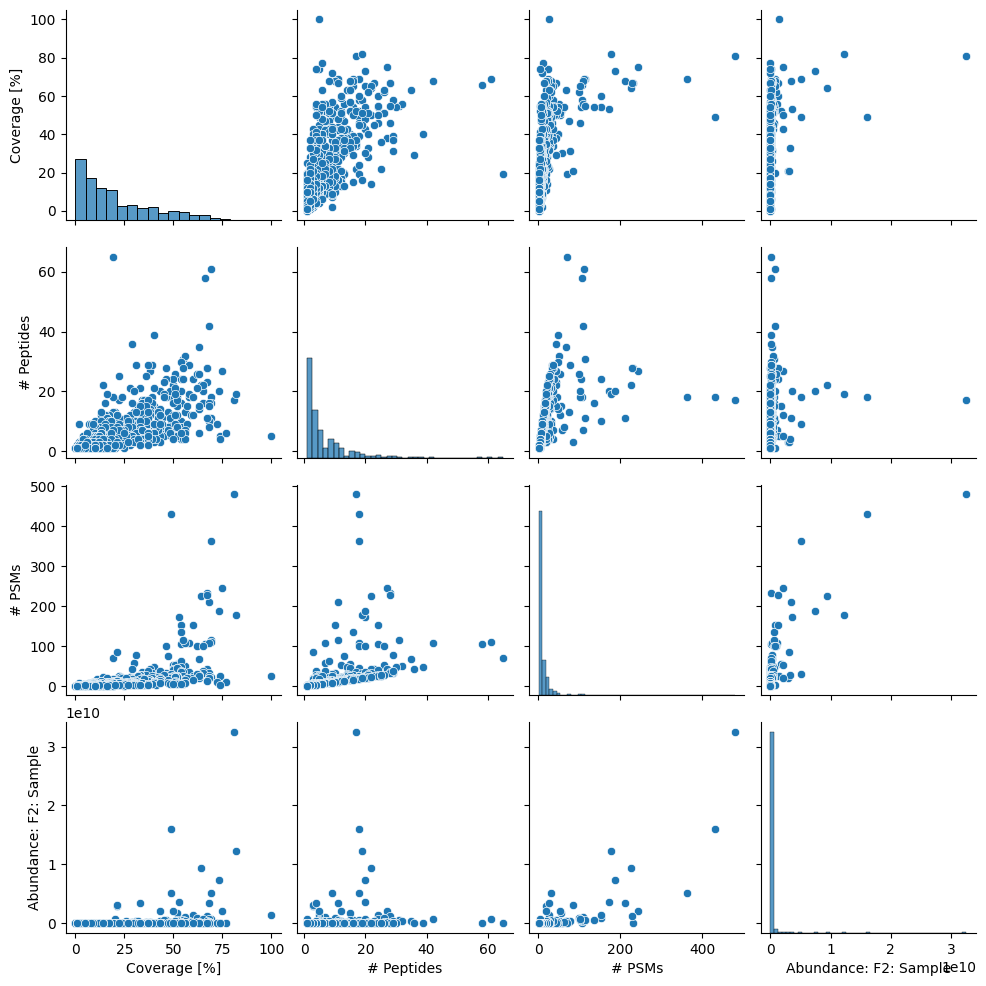

In [31]:
import seaborn as sns

sns.pairplot(df[['Coverage [%]', '# Peptides', '# PSMs', 'Abundance: F2: Sample']])
plt.show()
